# Territorial Digital Divide – Geospatial Raster Analysis
**Cusco, Peru | NASA VNL × Mobile Coverage**

Pipeline measuring digital inequality using nighttime radiance and mobile network density as proxies for urbanization and internet access.

---
## Setup

In [2]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.crs import CRS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter
from scipy import stats
import seaborn as sns
import pandas as pd
from pathlib import Path

# Paths
DATA_DIR   = Path('../data')
OUTPUT_DIR = Path('../output')
OUTPUT_DIR.mkdir(exist_ok=True)

VNL_PATH  = DATA_DIR / 'VNL_cusco_2025.tif'
KERN_PATH = DATA_DIR / 'kernel_cobmovil2019_50m.tif'

---
## Steps 0–1 | Load & Inspect Rasters

In [3]:
def inspect_raster(path: Path, label: str) -> dict:
    """Open a raster and print its key metadata."""
    with rasterio.open(path) as src:
        info = {
            'label':      label,
            'crs':        src.crs.to_string(),
            'width':      src.width,
            'height':     src.height,
            'count':      src.count,
            'nodata':     src.nodata,
            'bounds':     src.bounds,
            'res_x':      src.res[0],
            'res_y':      src.res[1],
            'dtype':      src.dtypes[0],
        }
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  CRS          : {info['crs']}")
    print(f"  Dimensions   : {info['height']} rows × {info['width']} cols")
    print(f"  Bands        : {info['count']}")
    print(f"  Data type    : {info['dtype']}")
    print(f"  NoData value : {info['nodata']}")
    print(f"  Bounds       : {info['bounds']}")
    print(f"  Pixel res    : {info['res_x']:.6f} × {info['res_y']:.6f} (x, y)")
    return info

vnl_info  = inspect_raster(VNL_PATH,  'VNL_cusco_2025.tif  (NASA Nighttime Radiance)')
kern_info = inspect_raster(KERN_PATH, 'kernel_cobmovil2019_50m.tif  (Mobile Coverage Kernel)')


  VNL_cusco_2025.tif  (NASA Nighttime Radiance)
  CRS          : EPSG:4326
  Dimensions   : 1081 rows × 961 cols
  Bands        : 1
  Data type    : float32
  NoData value : None
  Bounds       : BoundingBox(left=-74.00208248534999, bottom=-15.50208405735, right=-69.99791578664998, top=-10.99791735465)
  Pixel res    : 0.004167 × 0.004167 (x, y)

  kernel_cobmovil2019_50m.tif  (Mobile Coverage Kernel)
  CRS          : EPSG:32719
  Dimensions   : 6116 rows × 7754 cols
  Bands        : 1
  Data type    : float32
  NoData value : -3.4028234663852886e+38
  Bounds       : BoundingBox(left=-43080.11101302641, bottom=8337100.058809407, right=344619.88898697356, top=8642900.058809407)
  Pixel res    : 50.000000 × 50.000000 (x, y)


---
## Step 2 | Reproject & Align Connectivity to VNL Grid

In [4]:
with rasterio.open(VNL_PATH) as vnl_src:
    vnl_meta    = vnl_src.meta.copy()
    vnl_data    = vnl_src.read(1).astype(np.float32)
    vnl_nodata  = vnl_src.nodata
    vnl_crs     = vnl_src.crs
    vnl_transform = vnl_src.transform

with rasterio.open(KERN_PATH) as kern_src:
    kern_crs = kern_src.crs

    # Calculate transform from UTM-19S → WGS84 with VNL dimensions
    dst_transform, dst_width, dst_height = calculate_default_transform(
        kern_crs, vnl_crs,
        kern_src.width, kern_src.height,
        *kern_src.bounds
    )

    # Reproject connectivity to a temporary array in WGS84
    kern_reprojected = np.zeros((vnl_data.shape[0], vnl_data.shape[1]), dtype=np.float32)

    reproject(
        source=rasterio.band(kern_src, 1),
        destination=kern_reprojected,
        src_transform=kern_src.transform,
        src_crs=kern_crs,
        dst_transform=vnl_transform,   # align to VNL grid
        dst_crs=vnl_crs,
        resampling=Resampling.bilinear
    )

print(f"VNL shape           : {vnl_data.shape}")
print(f"Connectivity shape  : {kern_reprojected.shape}")
print(f"Grids aligned       : {vnl_data.shape == kern_reprojected.shape}")

VNL shape           : (1081, 961)
Connectivity shape  : (1081, 961)
Grids aligned       : True


---
## Step 3 | Percentile Normalization [0, 1]

In [5]:
def normalize_percentile(arr: np.ndarray, nodata=None, p_low=2, p_high=98) -> np.ndarray:
    """Clip to [p_low, p_high] percentile and scale to [0, 1]. NoData and negatives → 0."""
    out = arr.copy().astype(np.float32)

    # Mask nodata and negatives
    if nodata is not None:
        out[out == nodata] = np.nan
    out[out < 0] = np.nan

    valid = out[~np.isnan(out)]
    lo, hi = np.percentile(valid, p_low), np.percentile(valid, p_high)
    print(f"  p{p_low}={lo:.4f}  p{p_high}={hi:.4f}")

    out = np.clip(out, lo, hi)
    out = (out - lo) / (hi - lo)
    out = np.nan_to_num(out, nan=0.0)   # replace remaining NaN → 0
    return out

print("VNL normalization:")
vnl_norm = normalize_percentile(vnl_data, nodata=vnl_nodata)

print("Connectivity normalization:")
conn_norm = normalize_percentile(kern_reprojected)

print(f"\nVNL  norm range  : [{vnl_norm.min():.4f}, {vnl_norm.max():.4f}]")
print(f"Conn norm range  : [{conn_norm.min():.4f}, {conn_norm.max():.4f}]")

VNL normalization:
  p2=0.0000  p98=0.6334
Connectivity normalization:
  p2=0.0000  p98=0.0000

VNL  norm range  : [0.0000, 1.0000]
Conn norm range  : [0.0000, 1.0000]


---
## Step 4 | VNL Map: Raw vs. Normalized

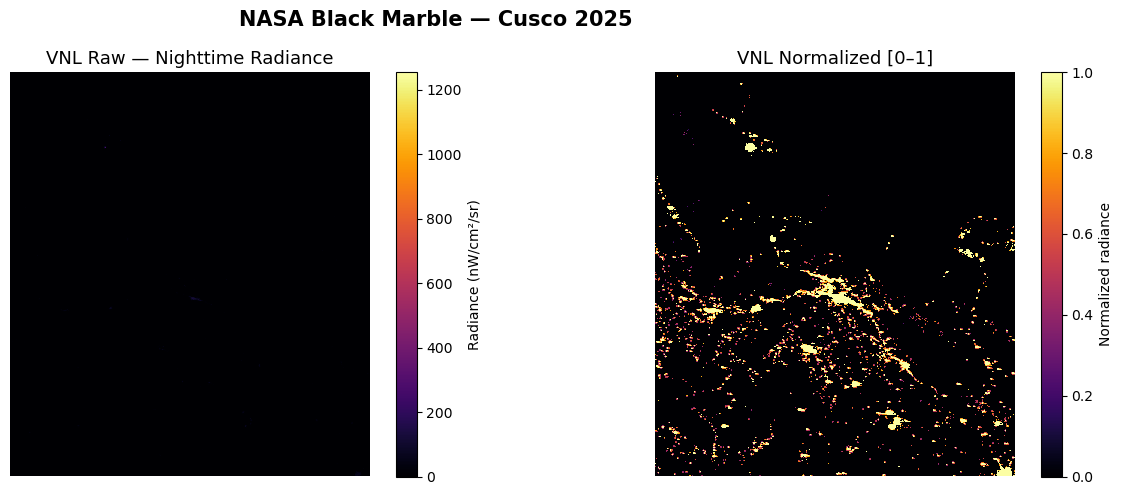

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw VNL (mask nodata)
raw_display = vnl_data.copy().astype(np.float32)
if vnl_nodata is not None:
    raw_display[raw_display == vnl_nodata] = np.nan
raw_display[raw_display < 0] = np.nan

im0 = axes[0].imshow(raw_display, cmap='inferno', interpolation='nearest')
axes[0].set_title('VNL Raw — Nighttime Radiance', fontsize=13)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='Radiance (nW/cm²/sr)')

im1 = axes[1].imshow(vnl_norm, cmap='inferno', vmin=0, vmax=1, interpolation='nearest')
axes[1].set_title('VNL Normalized [0–1]', fontsize=13)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='Normalized radiance')

fig.suptitle('NASA Black Marble — Cusco 2025', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 5 | IBD & EDT Indices

IBD range : [-1.0000, 1.0000]
EDT range : [0.0000, 1.0000]


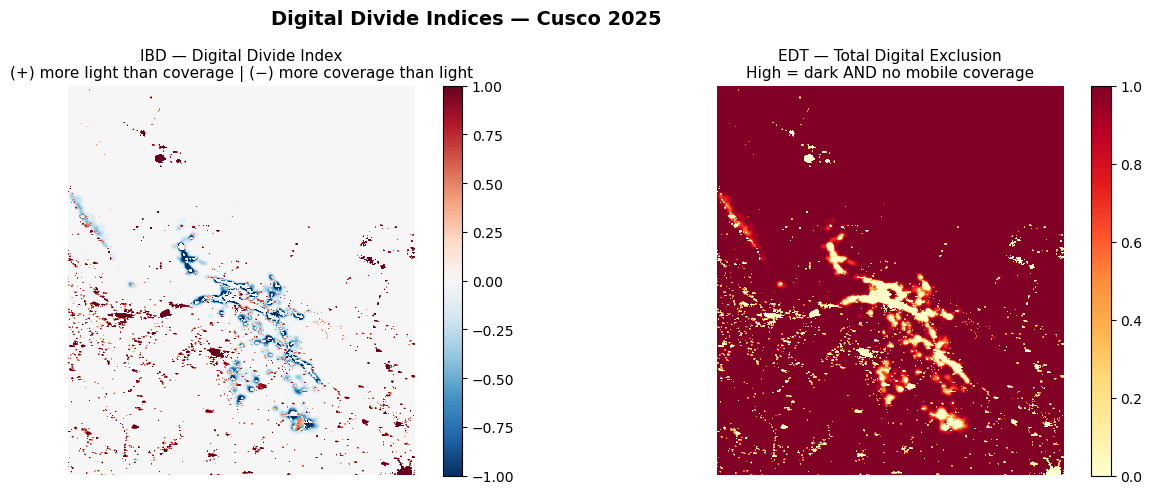

In [7]:
# IBD: Digital Divide Index  →  range [-1, 1]
# Positive = more light than connectivity (divide); negative = more coverage than light
ibd = vnl_norm - conn_norm

# EDT: Total Digital Exclusion  →  range [0, 1]
# High = dark AND no coverage (severe exclusion)
edt = (1 - vnl_norm) * (1 - conn_norm)

print(f"IBD range : [{ibd.min():.4f}, {ibd.max():.4f}]")
print(f"EDT range : [{edt.min():.4f}, {edt.max():.4f}]")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(ibd, cmap='RdBu_r', vmin=-1, vmax=1, interpolation='nearest')
axes[0].set_title('IBD — Digital Divide Index\n(+) more light than coverage | (−) more coverage than light', fontsize=11)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(edt, cmap='YlOrRd', vmin=0, vmax=1, interpolation='nearest')
axes[1].set_title('EDT — Total Digital Exclusion\nHigh = dark AND no mobile coverage', fontsize=11)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

fig.suptitle('Digital Divide Indices — Cusco 2025', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 6 | Intervention Priority Classification (3 Levels)

 Level           Label  Pixels  Pct (%)
     1    Low priority   15829     1.52
     2 Medium priority   64135     6.17
     3   High priority  958877    92.30


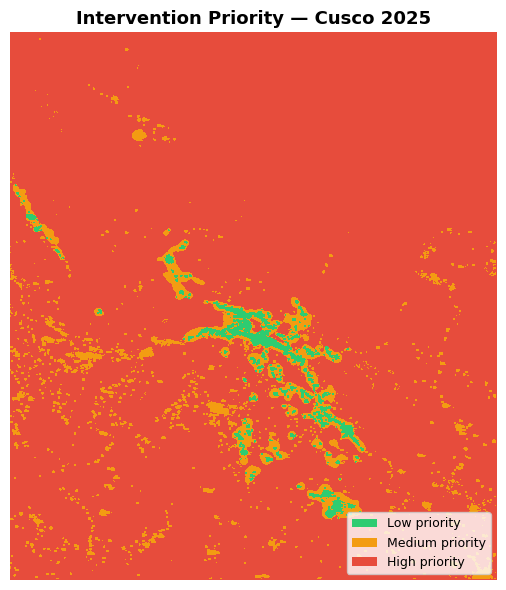

In [8]:
# Thresholds
VNL_THRESH  = 0.2   # below = low urbanization
CONN_THRESH = 0.2   # below = low connectivity

# Priority levels:
# 3 = High   : low VNL AND low connectivity  (most urgent)
# 2 = Medium : low VNL OR  low connectivity  (partial exclusion)
# 1 = Low    : neither condition             (well-served)
low_vnl  = vnl_norm  < VNL_THRESH
low_conn = conn_norm < CONN_THRESH

priority = np.ones(vnl_norm.shape, dtype=np.uint8)   # default: Low
priority[low_vnl | low_conn]   = 2                   # Medium
priority[low_vnl & low_conn]   = 3                   # High

# Statistics table
labels = {1: 'Low priority', 2: 'Medium priority', 3: 'High priority'}
total_px = priority.size
rows = []
for lvl, name in labels.items():
    count = int((priority == lvl).sum())
    rows.append({'Level': lvl, 'Label': name, 'Pixels': count, 'Pct (%)': round(count / total_px * 100, 2)})
df_priority = pd.DataFrame(rows)
print(df_priority.to_string(index=False))

cmap_p = mcolors.ListedColormap(['#2ecc71', '#f39c12', '#e74c3c'])
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(priority, cmap=cmap_p, vmin=1, vmax=3, interpolation='nearest')
legend_elements = [Patch(facecolor='#2ecc71', label='Low priority'),
                   Patch(facecolor='#f39c12', label='Medium priority'),
                   Patch(facecolor='#e74c3c', label='High priority')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.set_title('Intervention Priority — Cusco 2025', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Step 7 | Social Exclusion Risk + Gaussian Smoothing (σ=5)

Risk raw    range : [0.0000, 1.0000]
Risk smooth range : [0.0028, 1.0000]


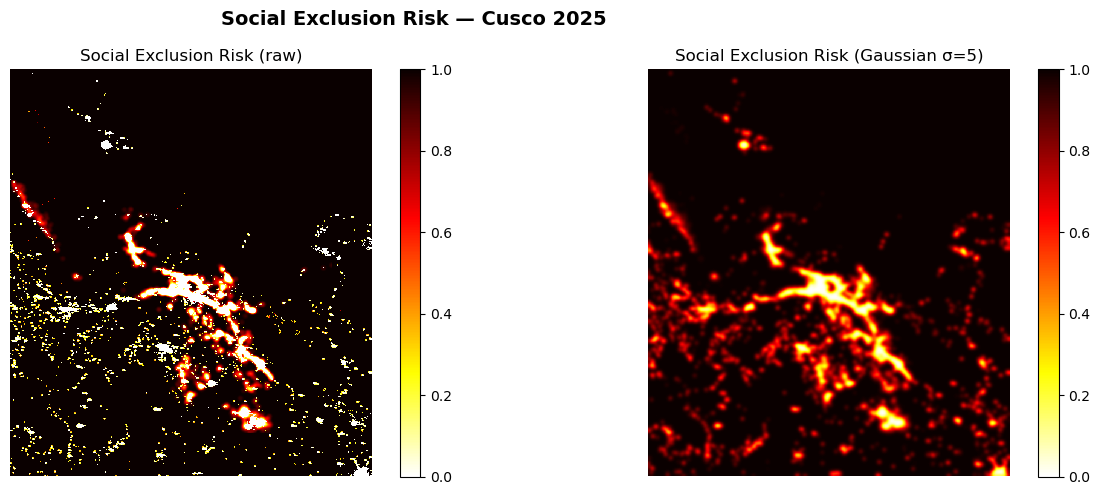

In [9]:
risk_raw    = edt * (1 - vnl_norm)
risk_smooth = gaussian_filter(risk_raw, sigma=5)

print(f"Risk raw    range : [{risk_raw.min():.4f}, {risk_raw.max():.4f}]")
print(f"Risk smooth range : [{risk_smooth.min():.4f}, {risk_smooth.max():.4f}]")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(risk_raw, cmap='hot_r', vmin=0, vmax=1, interpolation='nearest')
axes[0].set_title('Social Exclusion Risk (raw)', fontsize=12)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(risk_smooth, cmap='hot_r', vmin=0, vmax=1, interpolation='nearest')
axes[1].set_title('Social Exclusion Risk (Gaussian σ=5)', fontsize=12)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

fig.suptitle('Social Exclusion Risk — Cusco 2025', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()